# Prepare the features

- [X] BOP features arrangement and averagings
- [O] Library Features arrangement ad averaging
  average per polihedra.
  average per structure.
  atoms in each polyhedra.
- [X] Matminer features cleanup (decide min, max or avg)
- clear feature list from correlations
- outlier detection based on features
- Feature Distribution plots

# Included averages

- moments of the total density of states :  

$$ m_0^i = \left( \sum_{j} m_j^i \right)/N_{atoms} $$

- CP averaged moments, norm to total number of atoms:

$$ 
   m_{CP}^i =  \left( \sum_{j \in CP} m_j^i \right)/N_{atoms}
$$ 

- CP averaged moments, norm atoms in CP:

$$ 
   m_{CP}^i =  \left( \sum_{j \in CP} m_j^i \right)/N_{CP}
$$ 

# but I should also include:

- correlation matrices for pair of sets

 - input : features dataframes from prev steps
 - output: clean features dataframes into picles

In [1]:
from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools import GeneralFeaturizer as gf
dataset = 'Fe-Mo' #'Fe-Mo' #'Cr-Co-W'
NameForFile = 'FeMo'
descriptorlocation = os.path.join(dataset, 'Descriptors')
system = dataset.replace('-','')
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.Featurizer import Featurizer

In [2]:
import seaborn as sns

In [3]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=34)
plt.rc('xtick', labelsize=32)
plt.rc('ytick', labelsize=32)
plt.rc('axes', labelsize=34)
from matplotlib.lines import Line2D

In [4]:
CNListLocation = os.path.join(descriptorlocation,'CNList.pkl')
CNList = pd.read_pickle(CNListLocation)

In [5]:
from Tools.PredictionTools.MakeAtomsOjects import make_all_atoms_objects, permutate

In [6]:
binaryr = permutate('R', 2, 11)

In [7]:
atoms_objects_file = 'Fe-Mo/Atomsobjects/R_structures.pkl'

In [8]:
if os.path.exists(atoms_objects_file):
    AtomsObjects = pd.read_pickle(atoms_objects_file)
else:
    AtomsObjects = make_all_atoms_objects(binaryr)
    AtomsObjects = AtomsObjects.to_frame()
    AtomsObjects.columns = ['atoms']
    AtomsObjects.to_pickle(atoms_object_file)

In [9]:
RBS = AtomsObjects

In [10]:
RBS['num_atoms'] = RBS.atoms.map(len)

In [11]:
RBS[['Fe', 'Mo']] = pd.DataFrame.from_dict(
    RBS.atoms.map(lambda a: pd.Series(a.symbols).value_counts().to_dict()).to_dict(),
    orient = 'index'
).fillna(0)

# EASY FEATURES 

In [12]:
RBS['Fe_pv'] = RBS['Fe'] / RBS['num_atoms']
RBS['Mo_sv'] = 1 - RBS['Fe_pv']
RBS['Mag'] = 0 #NM
RBS['Structure'] = 4

In [13]:
RBS.index += '.NM'

In [14]:
RBS

,atoms,num_atoms,Fe,Mo,Fe_pv,Mo_sv,Mag,Structure
Fe_pv53.R-AAAAAAAAAAA.NM,"(Atom('Fe', [5.5758179773241885, 5.09570158339...",53,53.0,0.0,1.000000,0.000000,0,4
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,"(Atom('Fe', [5.599079257515289, 5.116959906890...",53,47.0,6.0,0.886792,0.113208,0,4
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,"(Atom('Fe', [5.583593282160754, 5.102807380847...",53,51.0,2.0,0.962264,0.037736,0,4
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,"(Atom('Fe', [5.606790225019939, 5.124006906896...",53,45.0,8.0,0.849057,0.150943,0,4
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,"(Atom('Fe', [5.599079257515289, 5.116959906890...",53,47.0,6.0,0.886792,0.113208,0,4
...,...,...,...,...,...,...,...,...
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM,"(Atom('Mo', [5.753096403345798, 5.257715113941...",53,6.0,47.0,0.113208,0.886792,0,4
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,"(Atom('Mo', [5.745773392292503, 5.251022664659...",53,8.0,45.0,0.150943,0.849057,0,4
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM,"(Atom('Mo', [5.767686757020587, 5.271049137510...",53,2.0,51.0,0.037736,0.962264,0,4
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,"(Atom('Mo', [5.753096403345798, 5.257715113941...",53,6.0,47.0,0.113208,0.886792,0,4


In [15]:
def get_nelem(a):
    return len(np.unique(a.get_chemical_symbols()))

In [16]:
RBS['nelem'] = RBS['atoms'].map(get_nelem)

In [17]:
RBS['nelem']

Fe_pv53.R-AAAAAAAAAAA.NM          1
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM    2
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM    2
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM    2
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM    2
                                 ..
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM    2
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM    2
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM    2
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM    2
Mo_sv53.R-BBBBBBBBBBB.NM          1
Name: nelem, Length: 2048, dtype: int64

##  More R structures

In [18]:
from BopFoxFeaturizer.brief_summary_parser import StructSummaryParser

In [19]:
ListOfBriefsumary = [
    'Fe-Mo/data/Fe_pv/briefsummary.dat',
    'Fe-Mo/data/Mo_sv/briefsummary.dat',
    'Fe-Mo/data/Fe_pv-Mo_sv/MoreRsBriefsummary.dat'
]

In [20]:
parser  = StructSummaryParser('Fe-Mo', ListOfBriefsummary=ListOfBriefsumary)#BriefSummary

In [21]:
orig_bs = parser.concat_briefsummaries(ListOfBriefsumary)

In [22]:
from BopFoxFeaturizer.Featurizer import Featurizer

In [23]:
Features  = Featurizer(orig_bs)

In [24]:
if 'Fe' in dataset:
    ground_states = Features.get_ground_states_energies(force_mag_phase=('Fe_pv', 'NM', 'fcc'))
else:
    ground_states = Features.get_ground_states_energies()

In [25]:
this_ground_states = {}
if 'Fe' in dataset:
    print('correcting for Fe')
    this_ground_states[('Fe_pv', 'FM')] = ground_states[('Fe_pv', 'FM', 'bcc')]
    this_ground_states[('Fe_pv', 'NM')] = ground_states[('Fe_pv', 'NM', 'hcp')]
if 'Mo' in dataset:
    this_ground_states[('Mo_sv', 'FM')] = ground_states[('Mo_sv', 'FM', 'bcc')]
    this_ground_states[('Mo_sv', 'NM')] = ground_states[('Mo_sv', 'NM', 'bcc')]

correcting for Fe


In [26]:
this_other_ground_states = {}
if 'Fe' in dataset:
    print('correcting for Fe')
    this_other_ground_states[('Fe_pv', 'FM')] = ground_states[('Fe_pv', 'FM', 'bcc')]
    this_other_ground_states[('Fe_pv', 'NM')] = ground_states[('Fe_pv', 'NM', 'fcc')]
if 'Mo' in dataset:
    this_other_ground_states[('Mo_sv', 'FM')] = ground_states[('Mo_sv', 'FM', 'bcc')]
    this_other_ground_states[('Mo_sv', 'NM')] = ground_states[('Mo_sv', 'NM', 'bcc')]

correcting for Fe


In [27]:
orig_bs['EF_fmbcc'] = Features.get_formation_energies(this_ground_states, force_reference_energy={'Fe_pv': ground_states[('Fe_pv', 'FM', 'bcc')]})
orig_bs['EF_nmhcp'] =  Features.get_formation_energies(this_ground_states)
orig_bs['EF_nmfcc'] =  Features.get_formation_energies(this_other_ground_states)

In [28]:
orig_bs.query('index.str.contains("R")')

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,15,38,53,0.283019,0.716981,0.155125,0.134967,0.112588
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,bulk R-BBBBBBBBBAA,15.771180 A,-10.065029,228.424823 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,8,45,53,0.150943,0.849057,0.464878,0.454127,0.442192
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,bulk R-BBBBBBBBBBA,15.923339 A,-10.206694,230.367641 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,6,47,53,0.113208,0.886792,0.424307,0.416244,0.407293
Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM,bulk R-AAABBBBBBBB,15.195143 A,-10.255394,247.124292 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,9,44,53,0.169811,0.830189,0.223966,0.211872,0.198445
Fe_pv3Mo_sv50.R-AABBBBBBBBB.NM,bulk R-AABBBBBBBBB,15.948587 A,-10.493489,240.778599 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,3,50,53,0.056604,0.943396,0.289153,0.285122,0.280646
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM,bulk R-ABBBBBBBBBB,16.207674 A,-10.574992,238.852230 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,1,52,53,0.018868,0.981132,0.308744,0.307400,0.305908
Mo_sv53.R.NM,bulk R,16.315439 A,-10.625314,238.808096 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,Mo_sv,,53,0,53,0.000000,1.000000,0.308969,0.308969,0.308969
Fe_pv53.R.NM,bulk R,10.496832 A,-8.018508,274.081057 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,Fe_pv,,53,0,53,1.000000,0.000000,0.236786,0.165561,0.086491
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM,bulk R-BAAAAAAAAAA,10.590332 A,-8.076914,273.598211 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,52,1,53,0.981132,0.018868,0.228927,0.159046,0.081468
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,bulk R-AAAAAAAAABA,10.670060 A,-8.146282,274.796406 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,51,2,53,0.962264,0.037736,0.210106,0.141569,0.065482


# CALCULATE FEATURES AND APPLY CN AVERAGE. THE ATOMS OBJECTS ARE ALREADY ORDERED !

In [29]:
from Tools.DatasetTools.GeneralFeaturizer import cn_persite
cn_persite['R']
for at in  RBS['atoms'][2]:
    print(at)
print(RBS.index[2])

Atom('Fe', [5.583593282160754, 5.102807380847488, 5.555099560384278], index=0)
Atom('Fe', [3.40353342339589, 3.112103794037992, 3.38904591128019], index=1)
Atom('Fe', [7.763653140925616, 7.093510967656983, 7.721153209488368], index=2)
Atom('Fe', [1.9111217335428652, 2.0162836649233804, 6.851198408955685], index=3)
Atom('Fe', [6.855779526133419, 1.5767594813539874, 2.292857577413509], index=4)
Atom('Fe', [2.473943886880756, 6.680704647165757, 2.0341080987140243], index=5)
Atom('Fe', [9.256064830778644, 8.189331096771598, 4.259000711812871], index=6)
Atom('Fe', [4.311407038188091, 8.628855280340987, 8.817341543355047], index=7)
Atom('Fe', [8.693242677440754, 3.5249101145292197, 9.076091022054529], index=8)
Atom('Fe', [2.432968727280905, 4.18035126210633, 7.496463148171309], index=9)
Atom('Fe', [7.4475578529956294, 1.9532439225780034, 4.496678053384418], index=10)
Atom('Fe', [4.687891179042978, 7.182276192693374, 2.499807946289788], index=11)
Atom('Fe', [8.734217837040603, 6.0252634995886

# Load Features 

In [30]:
model = '0.7projections_os'

In [31]:
results_pickle = os.path.join(descriptorlocation, f'Rstructures_FeMo_initial_{model}_table_WUBIND_16.pkl')

In [32]:
R_BOPS = pd.read_pickle(results_pickle)

In [33]:
R_BOPS.index += '.NM'

In [34]:
specialcolumns =['U_bind','U_bond_atom']#, 'U_bond_atom_list'] 
averaged_bop_file = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(results_pickle))

In [35]:
CNList = pd.Series([cn_persite['R']]*len(R_BOPS), index=R_BOPS.index)

In [36]:
featurescnav = {}
if os.path.exists(averaged_bop_file):
    featurescnav[model] = pd.read_pickle(averaged_bop_file).astype(float)  # for some reason some values are objects
else:
    columnstoexpand = R_BOPS.columns.drop(specialcolumns)
    df = gf.array_expansions(R_BOPS, columnstoexpand)
    ThisCoordination = CNList[R_BOPS.index]
    df = gf.featurize_dataframe(df, ThisCoordination)
    shape_factors = gf.get_shape_factors(df)
    featurescnav[model] = pd.concat([R_BOPS[specialcolumns[:-1]], df, shape_factors],  axis=1)
    featurescnav[model].to_pickle(averaged_bop_file)

In [37]:
featurescnav[model].index += '.NM'

In [38]:
RBS.columns

Index(['atoms', 'num_atoms', 'Fe', 'Mo', 'Fe_pv', 'Mo_sv', 'Mag', 'Structure',
       'nelem'],
      dtype='object')

In [39]:
featurescnav[model][['Structure', 'Mag']] = RBS[['Structure', 'Mag']]

# LOAD MODELS 

In [40]:
from Tools.DatasetTools.MLConveniences import filter_features

In [41]:
import joblib
import pickle

In [42]:
regressor_file = os.path.join(dataset, 'results', f'voting_regressor_KernelRidge.pkl')

In [43]:
voting_regressor = joblib.load(regressor_file)

# Prediction ! 

In [44]:
combi = ('Kernel Ridge', '0.7 Projections OS BOP')

In [45]:
Prediction_Values = pd.Series(voting_regressor[combi].predict(featurescnav[model]), index=featurescnav[model].index)

In [46]:
Prediction_Values

Fe_pv53.R-AAAAAAAAAAA.NM          0.191107
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM    0.054539
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM    0.107587
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM    0.055731
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM    0.052910
                                    ...   
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM    0.276074
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM    0.342576
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM    0.318736
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM    0.324531
Mo_sv53.R-BBBBBBBBBBB.NM          0.324671
Length: 2048, dtype: float64

In [47]:
bag_of_predictions = []
for name, estimator in voting_regressor[combi].named_estimators_.items():
    this_prediction = pd.Series(estimator.predict(featurescnav[model]), index = featurescnav[model].index)
    bag_of_predictions.append(this_prediction)

In [48]:
bag_of_predictions = pd.DataFrame(bag_of_predictions).transpose()

In [49]:
ERR = bag_of_predictions.std(axis=1)

In [50]:
BS = pd.read_pickle('Fe-Mo/FullyCuratedParsedBriefSummary.pkl')

In [51]:
calcs_R = BS[['Fe_pv','EF_nmhcp']].query('index.str.contains("R-")')

Text(0.5, 0, '$\\Delta E_f $(eV/at)')

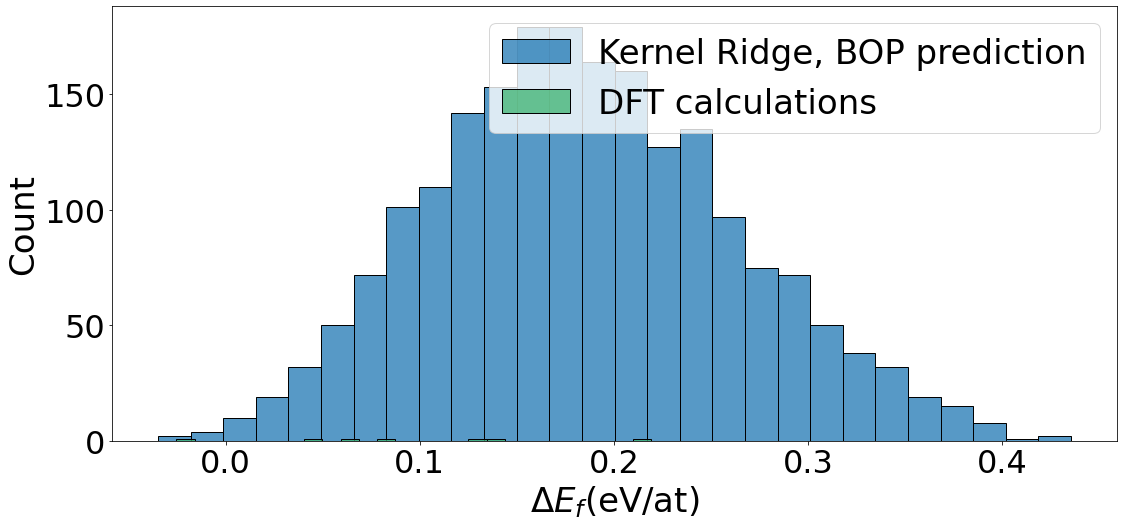

In [52]:
ax = sns.histplot(Prediction_Values, label = 'Kernel Ridge, BOP prediction')
ax = sns.histplot(calcs_R['EF_nmhcp'] , label = 'DFT calculations', binrange = [Prediction_Values.min(), Prediction_Values.max()], bins = 50, color = 'mediumseagreen')
ax.legend()
ax.set_xlabel(r'$\Delta E_f $(eV/at)')

Text(0, 0.5, '$\\Delta E_f$ (eV/atom)')

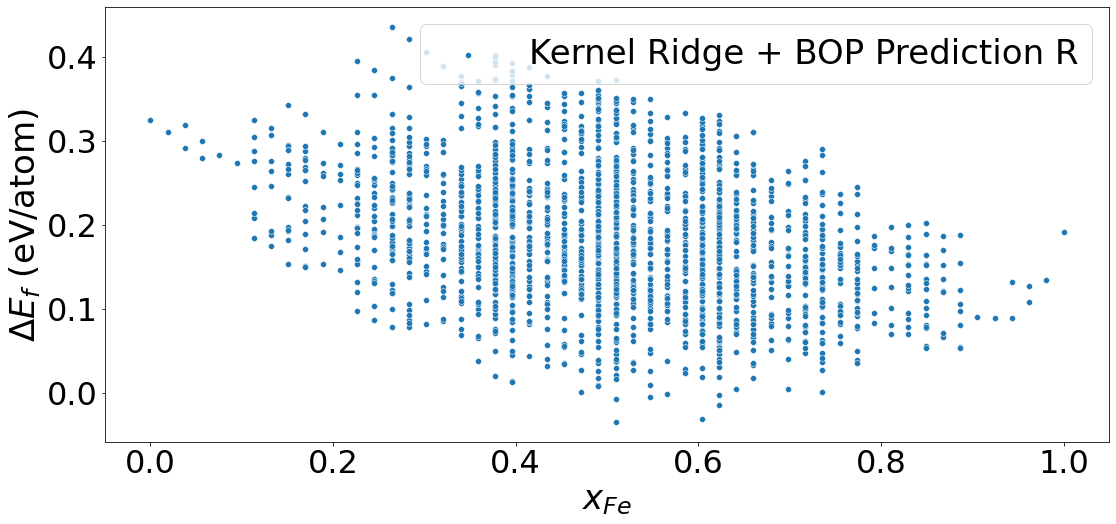

In [53]:
ax = sns.scatterplot(x = RBS['Fe_pv'], y = Prediction_Values, label = 'Kernel Ridge + BOP Prediction R')
ax.set_xlabel(r'$x_{Fe}$')
ax.set_ylabel(r'$\Delta E_f$ (eV/atom)')

In [54]:
Prediction_Values.to_pickle(os.path.join(dataset, 'results', 'R_structures_Predicted_EF_nmhcp.pkl'))

In [55]:
RBS['EF_nmhcp'] = Prediction_Values

# Recover learning prediction 

In [56]:
ModelName = 'Kernel Ridge'

In [57]:
#orig_bs = pd.read_pickle('Fe-Mo/ParsedBriefsummary.pkl')

In [58]:
orig_bs['Phase'] = orig_bs.index.str.split('.').map(lambda i: i[1]).str.split('-').map(lambda i: i[0])

In [59]:
orig_bs.query('index.str.contains("R")')

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc,Phase
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,15,38,53,0.283019,0.716981,0.155125,0.134967,0.112588,R
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,bulk R-BBBBBBBBBAA,15.771180 A,-10.065029,228.424823 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,8,45,53,0.150943,0.849057,0.464878,0.454127,0.442192,R
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,bulk R-BBBBBBBBBBA,15.923339 A,-10.206694,230.367641 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,6,47,53,0.113208,0.886792,0.424307,0.416244,0.407293,R
Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM,bulk R-AAABBBBBBBB,15.195143 A,-10.255394,247.124292 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,9,44,53,0.169811,0.830189,0.223966,0.211872,0.198445,R
Fe_pv3Mo_sv50.R-AABBBBBBBBB.NM,bulk R-AABBBBBBBBB,15.948587 A,-10.493489,240.778599 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,3,50,53,0.056604,0.943396,0.289153,0.285122,0.280646,R
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM,bulk R-ABBBBBBBBBB,16.207674 A,-10.574992,238.852230 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,1,52,53,0.018868,0.981132,0.308744,0.307400,0.305908,R
Mo_sv53.R.NM,bulk R,16.315439 A,-10.625314,238.808096 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,53,0,53,0.000000,1.000000,0.308969,0.308969,0.308969,R
Fe_pv53.R.NM,bulk R,10.496832 A,-8.018508,274.081057 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,53,0,53,1.000000,0.000000,0.236786,0.165561,0.086491,R
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM,bulk R-BAAAAAAAAAA,10.590332 A,-8.076914,273.598211 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,52,1,53,0.981132,0.018868,0.228927,0.159046,0.081468,R
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,bulk R-AAAAAAAAABA,10.670060 A,-8.146282,274.796406 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,51,2,53,0.962264,0.037736,0.210106,0.141569,0.065482,R


In [60]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    orig_bs.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=orig_bs.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'

In [61]:
orig_bs['Phase'] = Target_Class

I have a problem with one point 

In [62]:
#orig_bs = orig_bs.query('abs(Fe_pv - 0.72)>0.1')

In [63]:
OrigPhaseBS =  {
    '': {'DFT R':  orig_bs.query('Phase == "R"')}
}

In [64]:
OrigPhaseBS['']['DFT R']

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc,Phase
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,15,38,53,0.283019,0.716981,0.155125,0.134967,0.112588,R
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,bulk R-BBBBBBBBBAA,15.771180 A,-10.065029,228.424823 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,8,45,53,0.150943,0.849057,0.464878,0.454127,0.442192,R
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,bulk R-BBBBBBBBBBA,15.923339 A,-10.206694,230.367641 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,6,47,53,0.113208,0.886792,0.424307,0.416244,0.407293,R
Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM,bulk R-AAABBBBBBBB,15.195143 A,-10.255394,247.124292 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,9,44,53,0.169811,0.830189,0.223966,0.211872,0.198445,R
Fe_pv3Mo_sv50.R-AABBBBBBBBB.NM,bulk R-AABBBBBBBBB,15.948587 A,-10.493489,240.778599 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,3,50,53,0.056604,0.943396,0.289153,0.285122,0.280646,R
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM,bulk R-ABBBBBBBBBB,16.207674 A,-10.574992,238.852230 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,1,52,53,0.018868,0.981132,0.308744,0.307400,0.305908,R
Mo_sv53.R.NM,bulk R,16.315439 A,-10.625314,238.808096 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,53,0,53,0.000000,1.000000,0.308969,0.308969,0.308969,R
Fe_pv53.R.NM,bulk R,10.496832 A,-8.018508,274.081057 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,53,0,53,1.000000,0.000000,0.236786,0.165561,0.086491,R
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM,bulk R-BAAAAAAAAAA,10.590332 A,-8.076914,273.598211 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,52,1,53,0.981132,0.018868,0.228927,0.159046,0.081468,R
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,bulk R-AAAAAAAAABA,10.670060 A,-8.146282,274.796406 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,51,2,53,0.962264,0.037736,0.210106,0.141569,0.065482,R


# New Convex Hulls 

In [65]:
from Tools.DatasetTools.Tools import Plotting, PlottingChulls
P = Plotting()

In [66]:
target_case = 'EF_nmhcp'

In [67]:
from scipy.spatial import ConvexHull

In [68]:
points = RBS[['Fe_pv', 'EF_nmhcp']]

In [69]:
PhasesBS = {'': {'R' : RBS}}

In [70]:
from scipy.spatial import QhullError
def plot_chull(
    thePhasesBS,
    theproperty, 
    mag_list = None,
    plot_points = True,
    plot_only = [], 
    line_styles = '-',
    fig_= None,
    ax_ = None,
    components = ['Fe_pv', 'Mo_sv'], 
    palettename = 'tab20c'
):
    for mag, PhaseBS in  thePhasesBS.items():
        if mag not in mag_list:
            continue
        if len(plot_only) == 0:
            plot_only = PhaseBS.keys()
        points = P.get_x_ef_points(PhaseBS, components, property=theproperty)
        chulls =  P.get_convex_hulls(PhaseBS, components, getproperty = theproperty, return_points = False)
        palette = PlottingChulls.make_palette_forlist(plot_only, palette_name=palettename)
        if len(plot_only)>0:
            palette = {name: color for name, color in palette.items() if name in plot_only} 
        if ax_ is None:
            fig_,  ax_ = plt.subplots(figsize=(12,10))
            handles = []
            labels = []
        else:
            handles, labels = ax_.get_legend_handles_labels()
#        fig = figs_mag[mag]
#        ax = ax_mag[mag]
        for phase, chull in chulls.items():
            if len(plot_only) > 0:
                if phase not in plot_only:
                    continue
            for visible_facet in chull.simplices[chull.good]:
                l = ax_.plot(chull.points[visible_facet,0], chull.points[visible_facet,1],line_styles,  color=palette[phase], linewidth = 4, markersize=10, markeredgecolor='k')
                if plot_points:
                    l = ax_.plot(points[phase][components[0]] , points[phase][theproperty], 'o', color = palette[phase])
            handles.append(l[0])
            labels.append(phase)
        leg = ax_.legend(handles, labels, bbox_to_anchor=(1.01,1), title=mag)
        setlw = [ha.set_linewidth(5) for ha in leg.get_lines() ]
        ax_.set_ylabel(r'$\Delta E _f$ (eV/atom)')
        ax_.set_xlabel(rf'$x_{{{components[0]}}}$')
        fig_.tight_layout()
    return fig_, ax_

In [71]:
from matplotlib.lines import Line2D

In [72]:
palette1 = PlottingChulls.make_palette_forlist(['R'])
palette2 = PlottingChulls.make_palette_forlist(['R'], palette_name='copper')

In [73]:
L1 = Line2D([0],[0], marker = 'o', color=palette1['R'], markersize = 10, linewidth = 5)
L2 = Line2D([0],[0], marker = 'o', color=palette2['R'], markersize = 10, linewidth = 5 )

In [74]:
chulls= P.get_convex_hulls(PhasesBS[''],components=['Fe_pv', 'Mo_sv'],
                           viewpoint=[0.5, -10], getproperty='EF_nmhcp')

In [75]:
good_vertices = np.unique(chulls['R'].simplices[chulls['R'].good].ravel())

In [76]:
stds = bag_of_predictions.iloc[good_vertices].std(axis=1)

In [77]:
errs = pd.concat([stds, PhasesBS['']['R'][['Fe_pv', 'EF_nmhcp']].loc[stds.index]], axis = 1 )

In [78]:
errs.rename(columns={0: 'std'}, inplace=True)

In [79]:
errs.sort_values(by='Fe_pv', inplace=True)

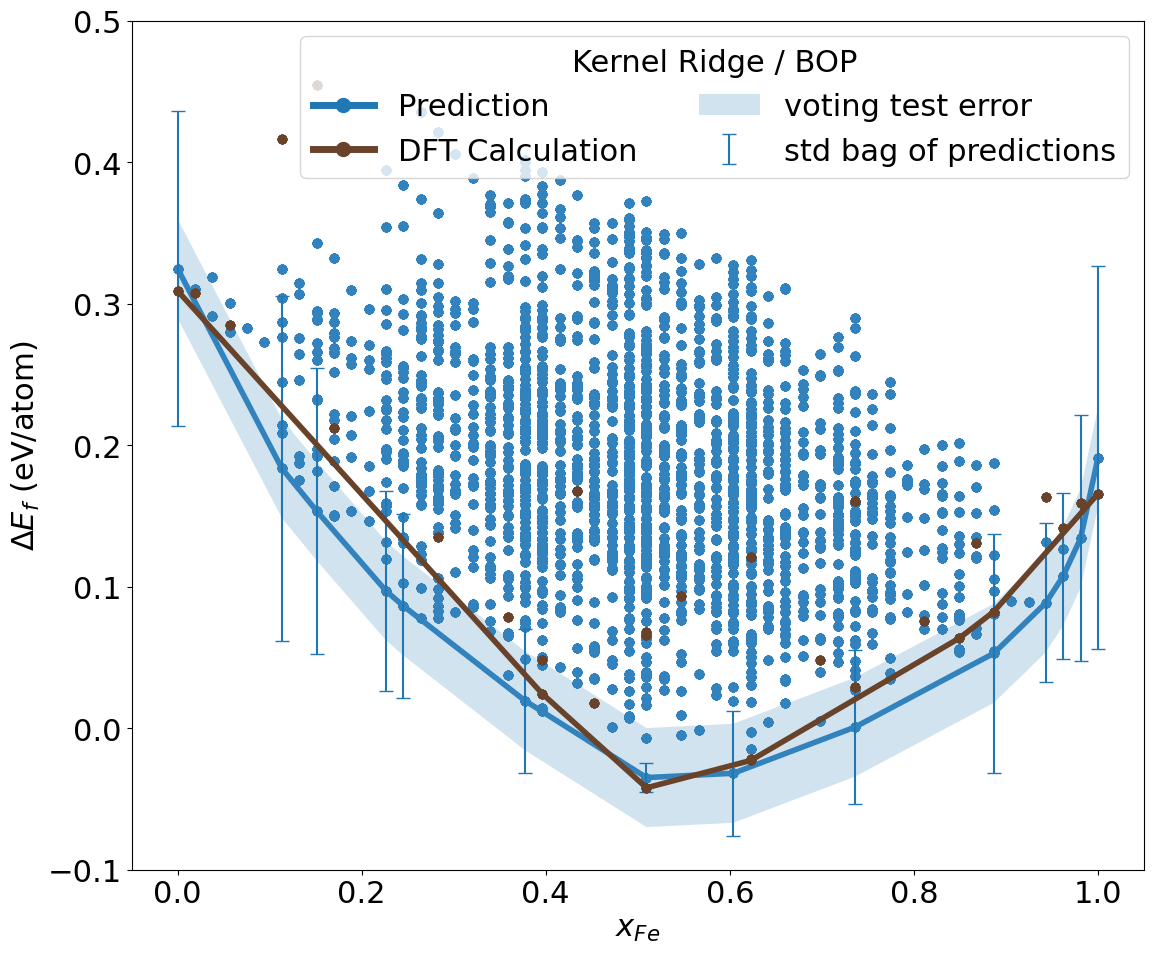

In [80]:
tfig, tax = plot_chull(PhasesBS, 'EF_nmhcp', mag_list=[''], plot_points=True, fig_ = None, ax_=None)
e = tax.errorbar(PhasesBS['']['R']['Fe_pv'][stds.index],PhasesBS['']['R']['EF_nmhcp'][stds.index],
             yerr=stds, capsize=5, fmt='none')
a = tax.fill_between(errs['Fe_pv'], errs['EF_nmhcp']+0.035, errs['EF_nmhcp']-0.035, alpha = 0.2, label='voting test error')
tfig, tax = plot_chull(OrigPhaseBS,
           'EF_nmhcp',
           mag_list=[''], 
           plot_points=True,
           fig_=tfig,
           ax_=tax, palettename='copper')
tax.set_xlabel(r'$x_{Fe}$')
tax.legend(
    [L1, L2, a, e],
    ['Prediction', 'DFT Calculation', 'voting test error', 'std bag of predictions'],
    ncol = 2,
    loc = 'upper right',
    title = 'Kernel Ridge / BOP'
)
tax.set_ylim([-0.1, 0.5])
file_name = os.path.join('Fe-Mo/graphs/R_structure_pred_vs_dft_Kernel Ridge_BOP.pdf')
tfig.tight_layout()
tfig.savefig(file_name)

# Comparision for the other phases 

In [81]:
def get_bs_byphase(theBS):
    verts = {}
    chulls = {}
    phasepoints = {}
    return {mag: {phase: theBS[(theBS.Phase == phase) & theBS.index.str.contains(mag)] for phase in theBS.Phase.unique()} for mag in ['FM', 'NM', '']}

In [82]:
orig_bs = orig_bs.loc[~orig_bs.index.str.contains('delta')]

In [83]:
OrigPhaseBS = get_bs_byphase(orig_bs)

In [84]:
predictedBS = pd.read_pickle('Fe-Mo/results/Fe-Mo_Kernel Ridge_PredictedBS.pkl')

In [85]:
predictedPhaseBS = get_bs_byphase(predictedBS)

In [86]:
plot_only = ['bcc', 'C14', 'sigma', 'mu', 'C36', 'A15', 'hcp']

In [90]:
dataset

'Fe-Mo'

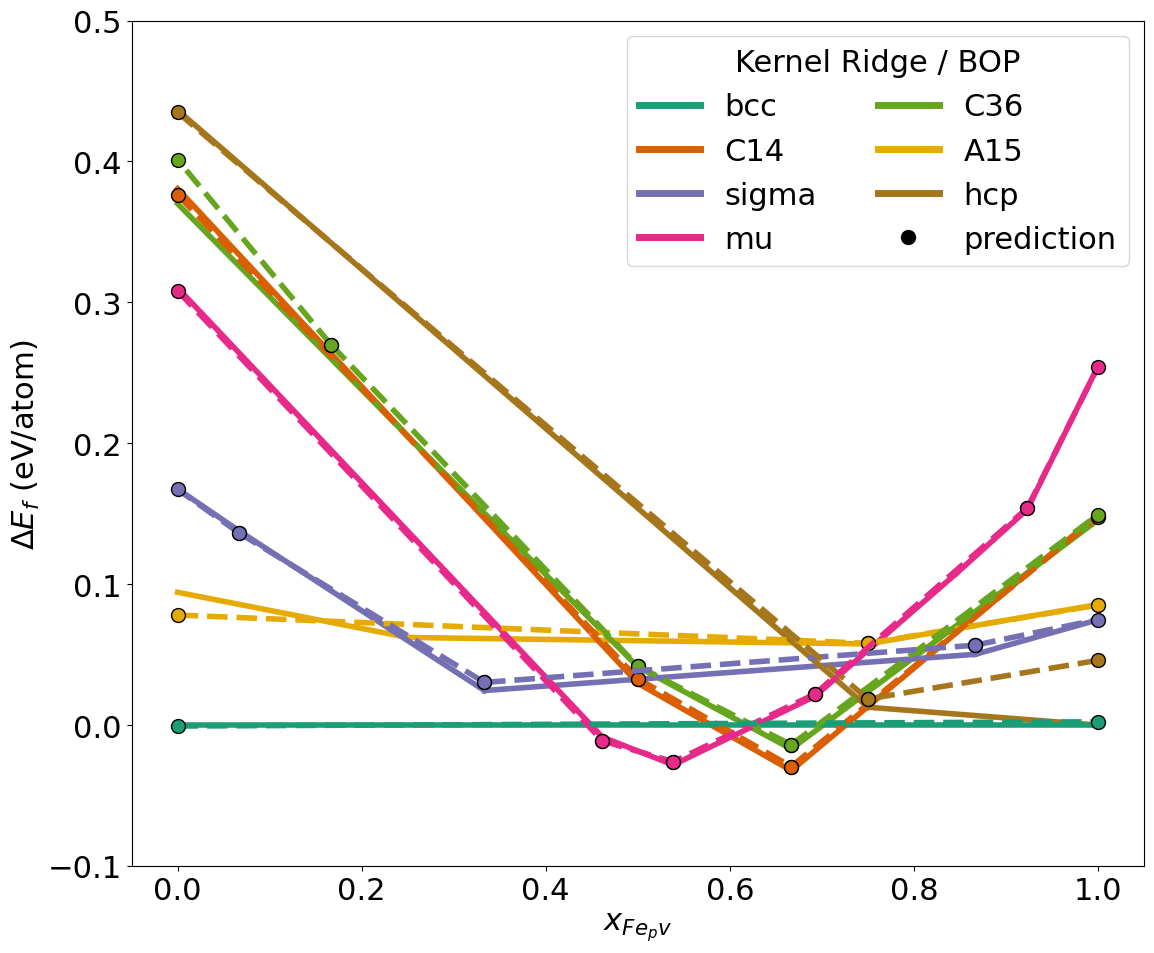

In [91]:
FeatureName = '0.7 Projections OS BOP'
ModelName = 'Kernel Ridge'
palettename = 'Dark2'
fig, ax = plot_chull(
    predictedPhaseBS, theproperty='EF_nmhcp', mag_list=[''], 
           components= [ 'Fe_pv', 'Mo'], plot_points = False,
    plot_only=plot_only, palettename=palettename
)

fig, ax = plot_chull(
    predictedPhaseBS, theproperty=f'EF_nmhcp_{FeatureName}', mag_list=[''], 
           components= [ 'Fe_pv', 'Mo'], plot_points = False,
    plot_only=plot_only, palettename=palettename, line_styles = '--o', fig_ = fig, ax_ = ax
)

ax.set_ylim([-0.1, 0.5])
palette = PlottingChulls.make_palette_forlist(plot_only, palette_name=palettename)
L = []
label = []
for name, color in palette.items():
    L.append(Line2D([0], [0], color = color, lw = 5))
    label.append(name)
L.append(Line2D([0],[0], linestyle = 'none', marker = 'o', color='k', linewidth=5, markersize=10))
label.append('prediction')
leg = ax.legend(L, label, loc = 'upper right', ncol =2, title='Kernel Ridge / BOP')
modelforfile=ModelName.replace(' ', '')
featureforfile=FeatureName.replace(' ', '')
fig.tight_layout()
file_name =os.path.join(dataset, 'graphs', f'{dataset}_CompareCHull_{modelforfile}_{featureforfile}.pdf')
fig.savefig(file_name)

# Bopxplots 

In [88]:
equals = RBS.index.intersection(calcs_R.index)

In [89]:
alldata = pd.concat([RBS['Fe_pv'] , bag_of_predictions], axis = 1).loc[equals]

In [90]:
melted = alldata.melt(id_vars='Fe_pv')

<AxesSubplot:xlabel='Fe_pv', ylabel='value'>

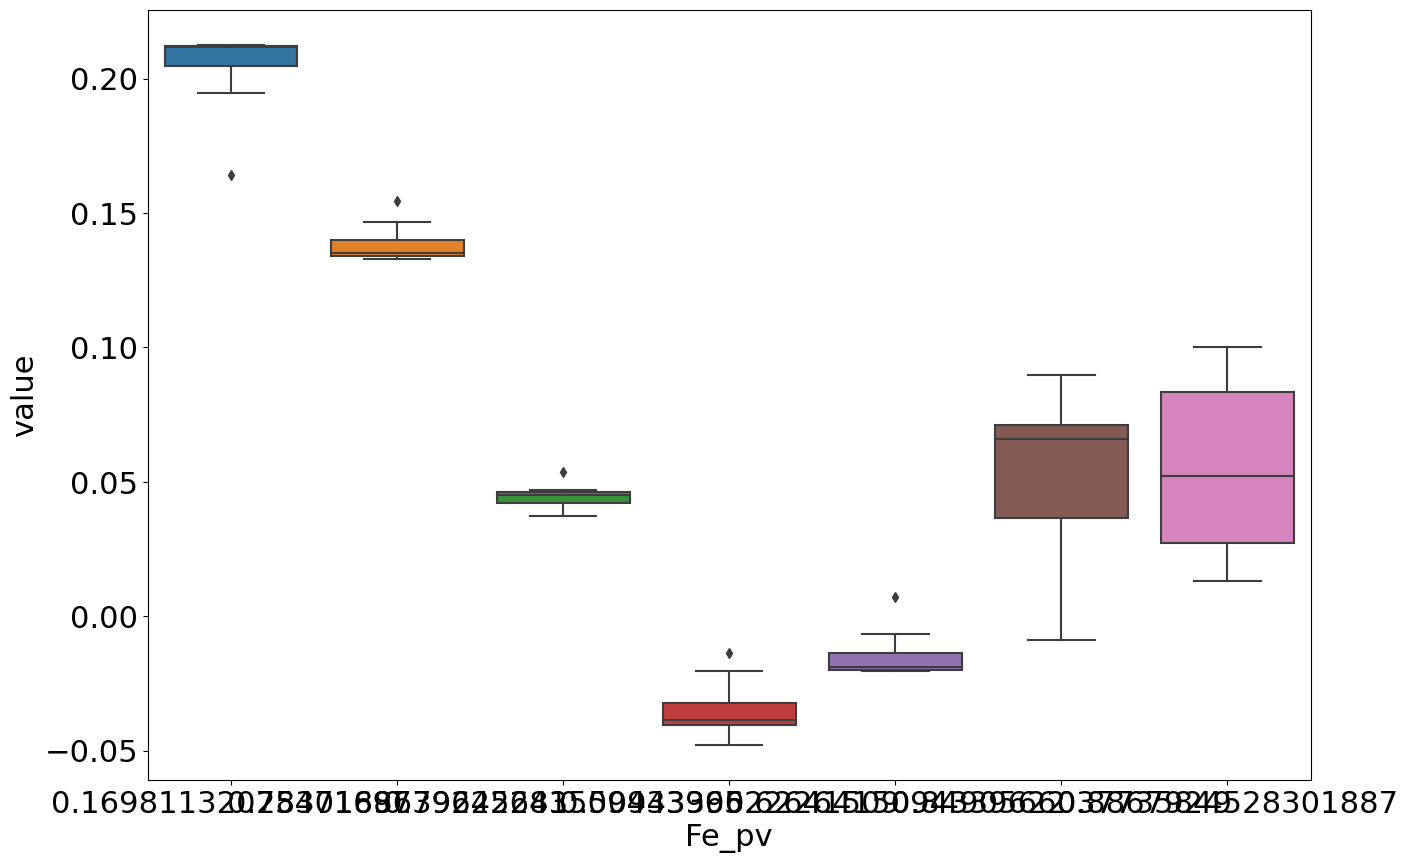

In [91]:
sns.boxplot(data=melted, x= 'Fe_pv', y = 'value')

In [92]:
alldata = alldata.loc[equals].melt(id_vars=['Fe_pv'])

In [93]:
sns.scatterplot(alldata

SyntaxError: unexpected EOF while parsing (400976186.py, line 1)

In [ ]:
ax = sns.scatterplot(x = RBS['Fe_pv'][equals], y = Prediction[equals], label = 'Prediction for R')
sns.scatterplot(data = calcs_R, x = 'Fe_pv', y = 'EF_nmhcp', ax = ax, ls='--', err=ERR[equals])
ax.set_xlabel(r'$x_{Fe}$')
ax.set_ylabel(r'$\Delta E_f$ (eV/atom)')

In [ ]:
ax = sns.scatterplot()

Coordination Number averages

In [ ]:
PyscalFeaturesFile = os.path.join(descriptorlocation, 'CNAVPyscal.pkl')

In [ ]:
bopmodels = ['canonical', 'projections', 'projections_os']
bopfeaturesfile = {model: os.path.join(descriptorlocation, f'curated_{system}_initial_{model}_table_WUBIND_16.pkl') for model in bopmodels}

In [ ]:
PyscalFeatures = pd.read_pickle(PyscalFeaturesFile)
BopFeatures = {model: pd.read_pickle(modelfile) for model, modelfile in bopfeaturesfile.items()}
AtomicFeatures = pd.read_pickle(AtomicFeaturesFile)
CompositionFeatures = pd.read_pickle(CompositionFeaturesFile)

# Outlier detection 

I know there are outliers. It is enaugh with looking at the following plots:

In [ ]:
BopFeatures['canonical']

In [ ]:
sns.histplot(BopFeatures['canonical']['U_bond_atom_list_1_0'])

# compiling FULL features 

In [ ]:
AllFeatures = [AtomicFeatures,CompositionFeatures, BopFeatures['canonical'] ] # 

In [ ]:
FullSetOfFeatures = pd.concat(AllFeatures, axis = 1)

# categorical features transformation

In [ ]:
from sklearn import set_config
from sklearn.compose import make_column_selector
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import make_pipeline

In [ ]:
cat_selector = make_column_selector(dtype_include=object)
categorical_features_names = cat_selector(FullSetOfFeatures)
CategoricalFeatures = FullSetOfFeatures[categorical_features_names]

In [ ]:
oencoder = OrdinalEncoder()
oencoder.fit(X=CategoricalFeatures)
replace_categorical_features_values  = oencoder.transform(CategoricalFeatures)

In [ ]:
FullSetOfFeatures[categorical_features_names] = replace_categorical_features_values

In [ ]:
FullSetOfFeatures[categorical_features_names]

# Fix Column Names  

In [ ]:
def fix_column_name(thecolumn):
    return thecolumn.replace(' ','_')

In [ ]:
columns = FullSetOfFeatures.columns

In [ ]:
newcolumns = {col: fix_column_name(col) for col in columns}

In [ ]:
FullSetOfFeatures.rename(columns=newcolumns, inplace=True)

In [ ]:
FullSetOfFeatures

# Unsupervised feature selection 

## Variance Threashold

remove features with low variance

TODO: for each separate set of features and save clean pickles

In [ ]:
from sklearn.feature_selection import VarianceThreshold

In [ ]:
selector = VarianceThreshold()

In [ ]:
variance_reduced = selector.fit_transform(FullSetOfFeatures)

In [ ]:
selectedfeatures = selector.get_support()

In [ ]:
AfterVarianceFeatures = FullSetOfFeatures.iloc[:,selectedfeatures]

In [ ]:
AfterVarianceFeaturesLocation = os.path.join(descriptorlocation, 'FullSetOfFeatures.pkl')

In [ ]:
FullSetOfFeatures.to_pickle(AfterVarianceFeaturesLocation)

#  Correlation based feature selection

this is not started even. 

In [ ]:
CORR = AfterVarianceFeatures.corr().abs()

to facilitate higly correlations removal, I will see only the upper triangle of this simmetric matrix

In [ ]:
columns = np.full((CORR.shape[0],), True, dtype=bool)

In [ ]:
tri_upper_corr = CORR.where(np.triu(np.ones(CORR.shape), k=1).astype(bool))

In [ ]:
to_drop = [column for column in tri_upper_corr.columns if any(tri_upper_corr[column] > 0.98)]

In [ ]:
len(to_drop)

In [ ]:
plt.imshow(tri_upper_corr[tri_upper_corr>0.9])
plt.colorbar()

In [ ]:
plt.imshow(CORR)
plt.colorbar()